# RT-IDS: Real-Time Network Intrusion Detection for IoT
## PyTorch Deep Neural Network Baseline — CIC-IoT-2023 Dataset

Two classification granularities:

- **2-class** — Benign vs Attack (binary gate)
- **8-class** — Attack families (operational routing)

**Best practices applied:**
1. Raw per-attack CSV ingestion; label derived from folder name
2. Per-class subsampling at ingest to cap majorities
3. Lazy Polars → Zstd-compressed Parquet (fast reloads, low memory)
4. Stratified 70/15/15 train/val/test split
5. `RobustScaler` fit on train only (no test leakage)
6. Class-weighted Cross-Entropy loss (handles extreme imbalance)
7. Early stopping on validation loss
8. Per-mode per-class precision/recall/F1 + normalized confusion matrix
9. Unified comparison table across both tasks

## Methodological Decisions (preempting standard committee critiques)

These four choices shape every result below. They are deliberate, defensible, and called out here so they are not surprises during defense:

1. **39-feature CIC-IoT-2023 release (trimmed to 25 after EDA).** The official UNB CIC website distributes a 39-feature CSV version. Most published papers on this dataset use a 46-feature variant that is not available from the official source; results in this notebook will not be numerically directly comparable to those papers, and that is acknowledged as a scope decision rather than treated as a defect.
2. **Three split strategies, temporal as headline (2-class and 8-class only).** CIC-IoT-2023 flows captured ~50 ms apart in the same attack session look near-identical in the 39-feature representation. A pure random row split lets the model exploit within-session redundancy. We report **temporal** (per-folder, sort source CSVs, train on earliest 70%), **per-CSV** (`GroupShuffleSplit`), and **random** (parity with published numbers). Headline numbers are temporal. The gap between random and temporal quantifies session-level memorization on this dataset and is itself a finding.
3. **Random per-class subsampling with deduplication.** CIC-IoT-2023 contains ~24M exact duplicate rows out of ~46M. We `unique()` per attack folder before sampling, then random-sample to `MAX_ROWS_PER_CLASS` with a fixed seed. This is the dominant approach in the CIC-IoT-2023 literature; sequential `head()` sampling — used in earlier drafts — biases the model toward the opening minutes of each capture session.
4. **"Real-time" scoped to interactive single-flow inference, not line-rate.** The benchmark reports per-batch p50/p95/p99 and end-to-end latency including `scaler.transform`. The thesis claim is that latency is sufficient for an interactive demo (target <100 ms end-to-end). Line-rate gateway deployment (>1M flows/sec) is explicitly out of scope.

**Expected finding worth noting in advance:** the **Web** attack family (SQL injection, XSS, command injection, browser hijacking) is inherently weakly detectable from flow-level statistics alone — these are application-layer attacks and the 39 features describe transport-layer behavior. Lower per-class F1 on Web attacks, and Web↔Benign confusion in the 8-class matrix, is consistent with Neto et al. (2023) and is a property of the feature set, not a model failure.

In [1]:
import os
from pathlib import Path

import numpy as np
import polars as pl
import torch
from torch.utils.data import DataLoader

from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from ids.core.config import (
    DATASET_DIRECTORY, PARQUET_PATH, MODELS_DIR, MAX_ROWS_PER_CLASS,
    X_COLUMNS, Y_COLUMN, N_FEATURES, FLAG_COLUMNS, LOG_COLUMNS,
    MODES_TO_RUN, SPLITS_TO_RUN, BATCH_SIZE, N_EPOCHS, PATIENCE, LR, SEED,
    BATCH_SIZES, N_WARMUP, N_RUNS,
)
from ids.core.labels import DICT_8CLASSES, DICT_2CLASSES, remap_labels
from ids.data.preprocessing import SPLIT_FUNCS, fit_preprocess
from ids.core.models import IDSDataset, IDSModel, train_model, evaluate, device
from ids.training.benchmark import benchmark_model

In [2]:
print(f'Features: {N_FEATURES} | log1p: {len(LOG_COLUMNS)} | flags: {len(FLAG_COLUMNS)}')
print(f'Per-class cap: {MAX_ROWS_PER_CLASS:,}')
print(f'Modes to run: {MODES_TO_RUN}')
print(f'Splits to run: {SPLITS_TO_RUN}')
print(f'Device: {device}')

Features: 39 | log1p: 17 | flags: 22
Per-class cap: 200,000
Modes to run: ['2', '8']
Splits to run: ['random']
Device: mps


## Label Mappings

Three granularities derived from the 34 attack folders. Keys are **case-sensitive** and must match folder names exactly. An assert at ingest time catches unmapped folders.

---
## Phase 1: Data Ingestion

Build a single deduplicated, sampled, labeled parquet from the per-attack CSV folders. Three steps, each in its own cell:

1. **Discover** — list attack folders and validate them against the 34-class label dictionary.
2. **Process** — per folder: lazily scan CSVs, drop exact duplicates, random-sample to the per-class cap.
3. **Summarize & write** — report dataset-wide duplication totals, then write the parquet.

In [3]:
# Raw per-attack CSV folders feed only the (uncached) ingest path below.
# When data/CSV is absent we run off the cached parquet, so list+validate only if present.
if DATASET_DIRECTORY.exists():
    attack_folders = sorted(
        d for d in os.listdir(DATASET_DIRECTORY)
        if (DATASET_DIRECTORY / d).is_dir()
    )
    print(f'Found {len(attack_folders)} attack folders')

    unmapped = set(attack_folders) - set(DICT_8CLASSES.keys())
    if unmapped:
        raise ValueError(f'Unmapped folders (fix DICT_8CLASSES): {unmapped}')
else:
    attack_folders = []
    print(f'Raw {DATASET_DIRECTORY} not found — will use cached parquet (no ingest).')

Raw /Users/wolfpack/uni/thesis-ids/cic-iot2023-detection-system/data/CSV not found — will use cached parquet (no ingest).


### Per-folder loop: dedup + random sample

For each attack folder, lazily scan all CSVs, stamp `source_csv` (filename) and materialize, **drop exact duplicates**, then **randomly sample** `MAX_ROWS_PER_CLASS` rows with a fixed seed.

**Why random sample, not `head()`:** each attack folder is a concatenation of sequential capture sessions. `.head(N)` would systematically pull only from the earliest sessions, biasing the model toward whatever happened in the opening minutes. Random sampling with a fixed seed gives a representative cross-session sample while remaining reproducible.

**Why keep `source_csv`:** needed downstream for the per-CSV and temporal splits, which prevent within-session leakage that random row splitting cannot catch.

In [4]:
from ids.data.ingest import run_ingest

if PARQUET_PATH.exists():
    print(f'Cache found at {PARQUET_PATH}, skipping ingest.')
    _vc = pl.read_parquet(str(PARQUET_PATH), columns=[Y_COLUMN])[Y_COLUMN].value_counts()
    class_stats = {row[Y_COLUMN]: row['count'] for row in _vc.iter_rows(named=True)}
    total_raw = total_unique = total_kept = None
    frames = None
    del _vc
else:
    frames, total_raw, total_unique, total_kept, class_stats = run_ingest(
        attack_folders, DATASET_DIRECTORY, X_COLUMNS, Y_COLUMN, MAX_ROWS_PER_CLASS, SEED,
    )

Cache found at /Users/wolfpack/uni/thesis-ids/cic-iot2023-detection-system/data/cic_iot_2023.parquet, skipping ingest.


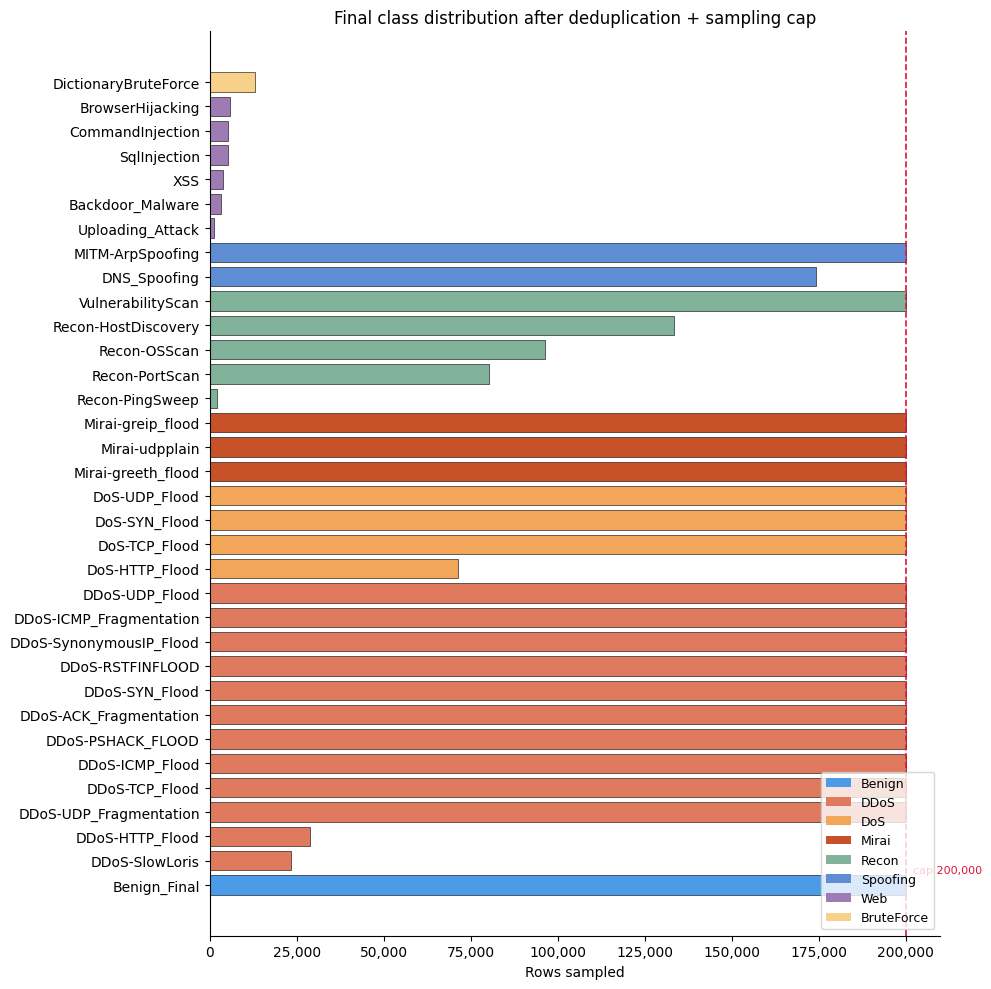

In [5]:
from matplotlib.ticker import FuncFormatter

# Plot: final sampled rows per class, grouped by family, sorted by count within each group
FAMILY_COLORS = { 'DDoS': '#e07a5f', 'DoS': '#f2a65a', 'Mirai': '#c7522a', 'Recon': '#81b29a', 'Spoofing': '#5f8dd3', 'Web': '#9e7bb5', 'BruteForce': '#f7d08a', 'Benign': '#4c9be8' }
FAMILY_ORDER = ['Benign', 'DDoS', 'DoS', 'Mirai', 'Recon', 'Spoofing', 'Web', 'BruteForce']

# Sort: primary by family order, secondary by count ascending within each family
folders_sorted = sorted(
    class_stats,
    key=lambda f: (FAMILY_ORDER.index(DICT_8CLASSES[f]), class_stats[f]),
)
counts = [class_stats[f] for f in folders_sorted]
bar_colors = [FAMILY_COLORS[DICT_8CLASSES[f]] for f in folders_sorted]

fig, ax = plt.subplots(figsize=(10, 10))
ax.barh(folders_sorted, counts, color=bar_colors, edgecolor='black', linewidth=0.4)
ax.axvline(MAX_ROWS_PER_CLASS, color='crimson', linestyle='--', linewidth=1.2)
ax.text(MAX_ROWS_PER_CLASS * 1.01, 0.4, f'cap {MAX_ROWS_PER_CLASS:,}',
        color='crimson', va='bottom', fontsize=8)

from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=FAMILY_COLORS[fam], label=fam) for fam in FAMILY_ORDER]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9)

ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.set_xlabel('Rows sampled')
ax.set_title('Final class distribution after deduplication + sampling cap')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('docs/report/figures/dist_class_bar.png', dpi=140, bbox_inches='tight')
plt.show()

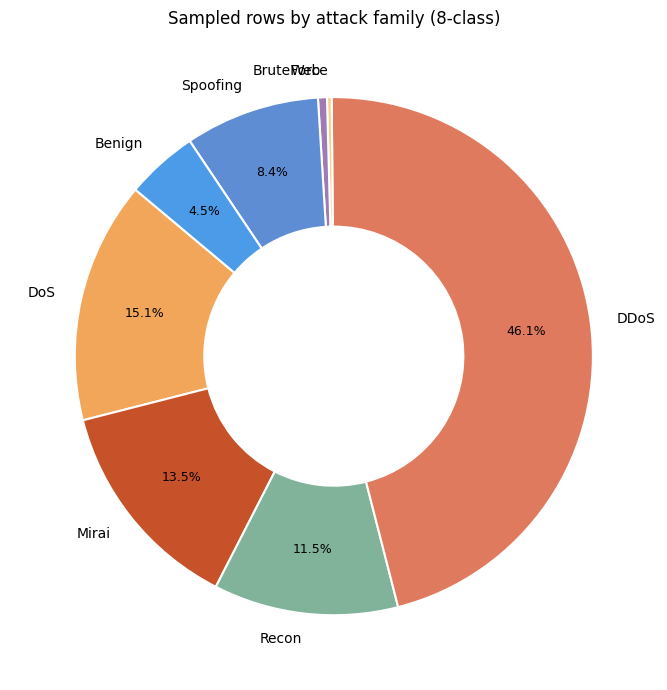

In [6]:
# Donut chart: share of total sampled rows per 8-class family
from collections import defaultdict

family_totals = defaultdict(int)
for folder, n in class_stats.items():
    family_totals[DICT_8CLASSES[folder]] += n

families = list(family_totals.keys())
totals = list(family_totals.values())
colors = [FAMILY_COLORS[f] for f in families]

fig, ax = plt.subplots(figsize=(7, 7))
pie_parts = ax.pie(
    totals, labels=families, colors=colors,
    autopct=lambda p: f'{p:.1f}%' if p > 2 else '',
    pctdistance=0.75, startangle=140,
    wedgeprops=dict(width=0.5, edgecolor='white', linewidth=1.5),
)
wedges, texts = pie_parts[0], pie_parts[1]
autotexts = pie_parts[2] if len(pie_parts) == 3 else []
for t in autotexts:
    t.set_fontsize(9)

ax.set_title('Sampled rows by attack family (8-class)')
plt.tight_layout()
plt.show()

### Dataset-wide totals

Sum the per-folder counters into a single duplication summary, then write the combined frame to parquet. Reporting the aggregate raw / unique / duplicate counts confirms the canonical CIC-IoT-2023 finding (~24M duplicates of ~46M raw rows) on this run, rather than leaving it implicit in the per-folder log.

In [7]:
from ids.data.ingest import plot_waterfall

if frames is not None:
    assert total_raw is not None and total_unique is not None and total_kept is not None
    fig = plot_waterfall(total_raw, total_unique, total_kept, MAX_ROWS_PER_CLASS, len(frames))
    fig.savefig('docs/report/figures/ingest_waterfall.png', dpi=140, bbox_inches='tight')
    plt.show()
    PARQUET_PATH.parent.mkdir(parents=True, exist_ok=True)
    pl.concat(frames).write_parquet(str(PARQUET_PATH), compression='zstd')
    print(f'Parquet saved to {PARQUET_PATH}')
else:
    print('Skipped - using existing parquet.')


Skipped - using existing parquet.


### Inspect the saved parquet

Reload from disk and report row counts per 34-class plus the number of distinct source CSVs per folder — the latter feeds the per-CSV and temporal split strategies in Phase 3.

In [8]:
df = pl.read_parquet(str(PARQUET_PATH))
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')

print('\nRows per 34-class:')
print(df[Y_COLUMN].value_counts().sort('count', descending=True))

print('\nDistinct source CSVs per attack folder (used by per-CSV / temporal splits):')
print(
    df.group_by(Y_COLUMN)
      .agg(pl.col('source_csv').n_unique().alias('n_csvs'))
      .sort('n_csvs', descending=True)
)

Rows: 4,448,253 | Columns: 41

Rows per 34-class:
shape: (34, 2)
┌───────────────────┬────────┐
│ Label             ┆ count  │
│ ---               ┆ ---    │
│ str               ┆ u32    │
╞═══════════════════╪════════╡
│ Mirai-greip_flood ┆ 200000 │
│ DDoS-RSTFINFLOOD  ┆ 200000 │
│ DoS-UDP_Flood     ┆ 200000 │
│ MITM-ArpSpoofing  ┆ 200000 │
│ DDoS-UDP_Flood    ┆ 200000 │
│ …                 ┆ …      │
│ SqlInjection      ┆ 5245   │
│ XSS               ┆ 3846   │
│ Backdoor_Malware  ┆ 3215   │
│ Recon-PingSweep   ┆ 2262   │
│ Uploading_Attack  ┆ 1252   │
└───────────────────┴────────┘

Distinct source CSVs per attack folder (used by per-CSV / temporal splits):
shape: (34, 2)
┌────────────────────┬────────┐
│ Label              ┆ n_csvs │
│ ---                ┆ ---    │
│ str                ┆ u32    │
╞════════════════════╪════════╡
│ Mirai-greeth_flood ┆ 29     │
│ DDoS-ICMP_Flood    ┆ 27     │
│ Mirai-udpplain     ┆ 25     │
│ Mirai-greip_flood  ┆ 22     │
│ DDoS-UDP_Flood     ┆ 21   

---
## Phase 2: Cleaning

1. Drop null-label rows (defensive — labels come from folder names so should be zero)
2. Replace inf/-inf with null (handled by train-fit median imputation later, in `cell:scale`)
3. `log1p(x)` on continuous features — compresses heavy-tailed rate/size distributions. The CIC-IoT-2023 continuous features are all non-negative by construction, so no `abs()` wrapper is needed.

**What's NOT done here:** median imputation. It moved to `cell:scale` so medians are fit on the **train split only** instead of the full pool. This eliminates a (very small) source of test-set leakage.

In [9]:
rows_before = df.shape[0]
df = df.drop_nulls(subset=[Y_COLUMN])
print(f'Dropped {rows_before - df.shape[0]:,} null-label rows ({df.shape[0]:,} remaining)')

Dropped 0 null-label rows (4,448,253 remaining)


In [10]:
df = df.with_columns([
    pl.when(pl.col(c).is_infinite()).then(None).otherwise(pl.col(c)).alias(c)
    for c in X_COLUMNS
])

cols_with_nulls = {c: df[c].null_count() for c in X_COLUMNS if df[c].null_count() > 0}
print(f'{len(cols_with_nulls)} columns carry nulls (from inf→null replacement):')
for col, n in sorted(cols_with_nulls.items(), key=lambda x: -x[1]):
    print(f'  {col:<20} {n:>4} null rows')

6 columns carry nulls (from inf→null replacement):
  Rate                  162 null rows
  Variance              131 null rows
  Std                   130 null rows
  Tot size                1 null rows
  IAT                     1 null rows
  Number                  1 null rows


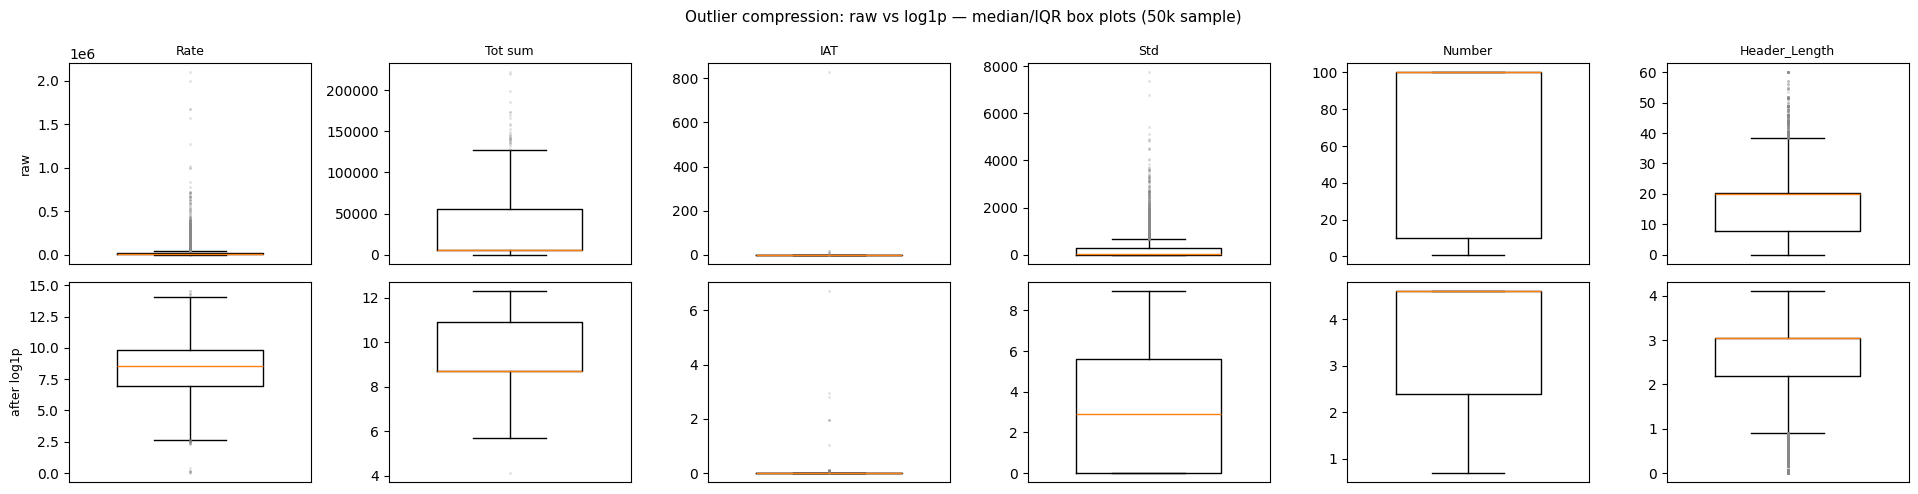

In [11]:
# Outlier structure: raw vs log1p box plots for the heavy-tailed continuous features.
# RobustScaler (applied later, per-split) centers on the median and scales by the IQR,
# so the box and whiskers below are exactly the statistics it relies on. This panel
# motivates both the log1p transform and the choice of RobustScaler over a mean/std scaler.
_n_box = min(50_000, df.shape[0])
_box_cols = ['Rate', 'Tot sum', 'IAT', 'Std', 'Number', 'Header_Length']
_box_sample = df.sample(n=_n_box, seed=SEED).select(_box_cols).to_numpy().astype(np.float32)

fig, axes = plt.subplots(2, len(_box_cols), figsize=(3.2 * len(_box_cols), 5))
_flier = dict(marker='.', markersize=2, alpha=0.25, markeredgecolor='#888')
for j, col in enumerate(_box_cols):
    raw = _box_sample[:, j]
    raw = raw[np.isfinite(raw)]
    axes[0, j].boxplot(raw, widths=0.6, flierprops=_flier)
    axes[0, j].set_title(col, fontsize=9)
    axes[0, j].set_xticks([])
    axes[1, j].boxplot(np.log1p(np.clip(raw, 0, None)), widths=0.6, flierprops=_flier)
    axes[1, j].set_xticks([])
axes[0, 0].set_ylabel('raw', fontsize=9)
axes[1, 0].set_ylabel('after log1p', fontsize=9)
fig.suptitle('Outlier compression: raw vs log1p — median/IQR box plots (50k sample)', fontsize=11)
plt.tight_layout()
plt.savefig('docs/report/figures/box_raw_vs_log1p.png', dpi=140, bbox_inches='tight')
plt.show()


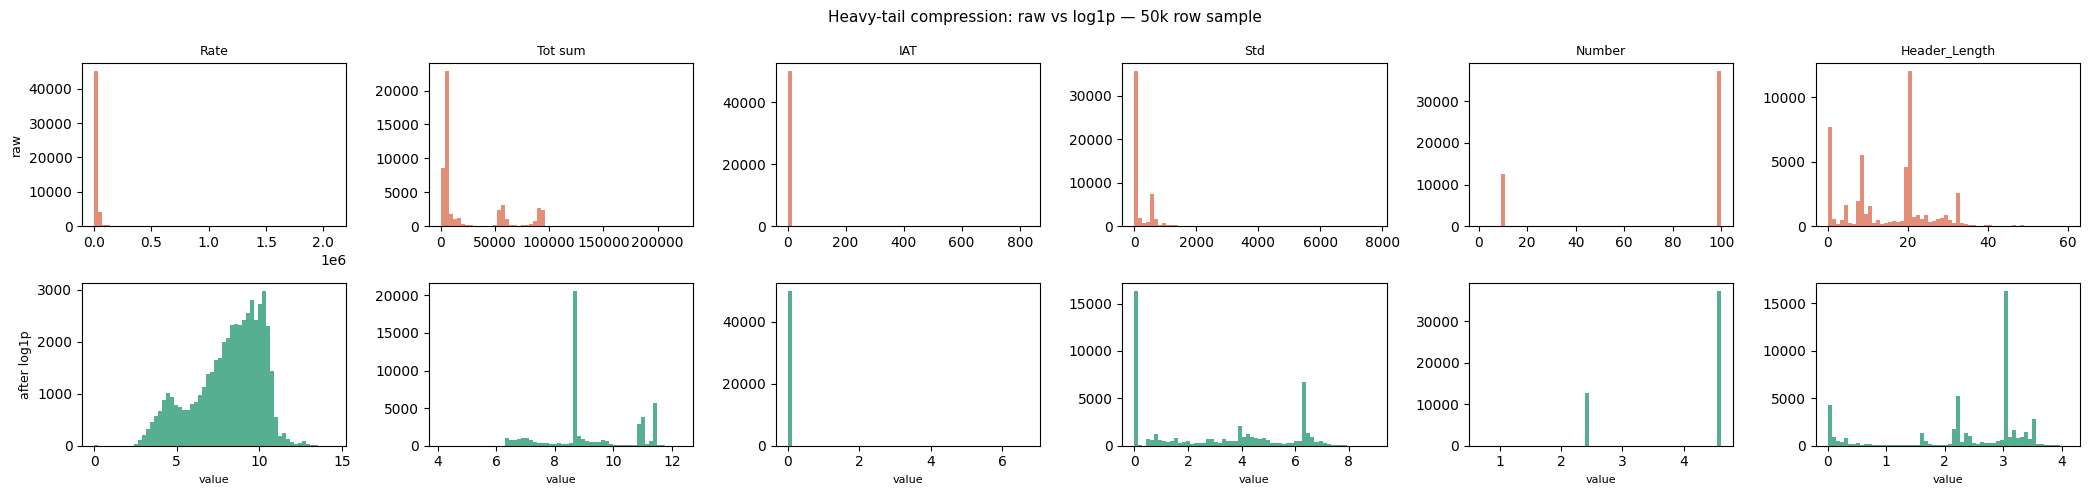

log1p applied to 17 continuous columns
Cleaned dataset: 4,448,253 rows (nulls retained for post-split imputation)


In [12]:
# Sample raw values before transformation for the visual comparison
_n = min(50_000, df.shape[0])
_sample = df.sample(n=_n, seed=SEED).select(LOG_COLUMNS).to_numpy().astype(np.float32)

_plot_cols = ['Rate', 'Tot sum', 'IAT', 'Std', 'Number', 'Header_Length']
fig, axes = plt.subplots(2, len(_plot_cols), figsize=(3.5 * len(_plot_cols), 5))
for j, col in enumerate(_plot_cols):
    idx = LOG_COLUMNS.index(col)
    raw = _sample[:, idx]
    raw = raw[np.isfinite(raw)]
    axes[0, j].hist(raw, bins=60, color='#e07a5f', edgecolor='none', alpha=0.85)
    axes[0, j].set_title(col, fontsize=9)
    axes[1, j].hist(np.log1p(np.clip(raw, 0, None)), bins=60, color='#3aa17e', edgecolor='none', alpha=0.85)
    axes[1, j].set_xlabel('value', fontsize=8)

axes[0, 0].set_ylabel('raw', fontsize=9)
axes[1, 0].set_ylabel('after log1p', fontsize=9)
fig.suptitle('Heavy-tail compression: raw vs log1p — 50k row sample', fontsize=11)
plt.tight_layout()
plt.show()

del _sample

df = df.with_columns([pl.col(c).log1p().alias(c) for c in LOG_COLUMNS])
print(f'log1p applied to {len(LOG_COLUMNS)} continuous columns')
print(f'Cleaned dataset: {df.shape[0]:,} rows (nulls retained for post-split imputation)')

### Feature Analysis

Two diagnostic checks before splitting, using the cleaned post-log1p dataset.

---

#### Variance check (binary flags)

For a binary random variable $X \in \{0, 1\}$ with $p = P(X=1)$:

$$\text{Var}(X) = p(1-p)$$

This is maximised at $p = 0.5$ (Var = 0.25) and approaches 0 when $p \to 0$ or $p \to 1$.
A threshold of $\text{Var} < 0.01$ implies the flag is set in fewer than ~1% of flows across the entire dataset — it is near-constant and contributes no discriminative signal to any classifier.

---

#### Pearson correlation (continuous features)

$$r_{XY} = \frac{\sum_i (x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_i (x_i - \bar{x})^2}\;\sqrt{\sum_i (y_i - \bar{y})^2}} \in [-1, 1]$$

$|r| \approx 1$ means the two features carry near-identical information: one is a linear function of the other.
Keeping both wastes a model parameter without adding information.

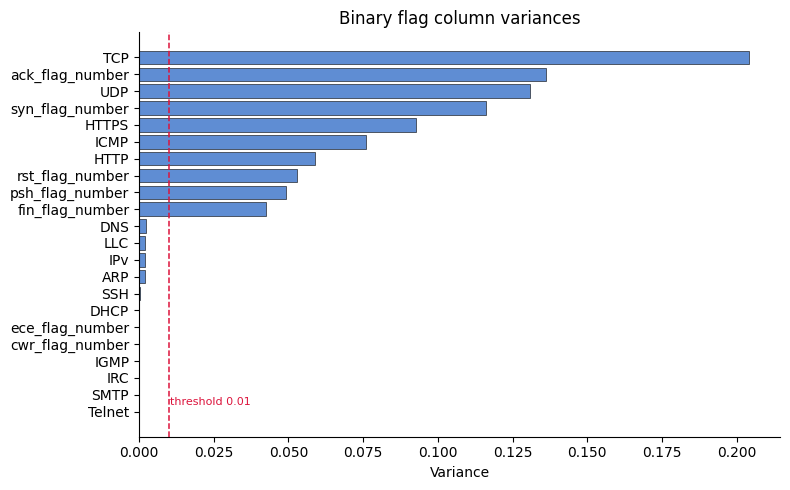

Near-constant flags (var < 0.01): ['ece_flag_number', 'cwr_flag_number', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'DHCP', 'ARP', 'IGMP', 'IPv', 'LLC']


In [13]:
_flag_vals = df.select(FLAG_COLUMNS).to_numpy().astype(np.float32)
_flag_var = _flag_vals.var(axis=0)

sorted_flags = sorted(zip(FLAG_COLUMNS, _flag_var), key=lambda x: x[1])
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh([f for f, _ in sorted_flags], [v for _, v in sorted_flags],
        color='#5f8dd3', edgecolor='black', linewidth=0.4)
ax.axvline(0.01, color='crimson', linestyle='--', linewidth=1.1)
ax.text(0.0105, 0.3, 'threshold 0.01', color='crimson', va='bottom', fontsize=8)
ax.set_xlabel('Variance')
ax.set_title('Binary flag column variances')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('docs/report/figures/flag_variances.png', dpi=140, bbox_inches='tight')
plt.show()

low_var = [(c, v) for c, v in zip(FLAG_COLUMNS, _flag_var) if v < 0.01]
if low_var:
    print(f'Near-constant flags (var < 0.01): {[c for c, _ in low_var]}')
else:
    print('All flag columns have variance >= 0.01 — none are near-constant.')
del _flag_vals, _flag_var

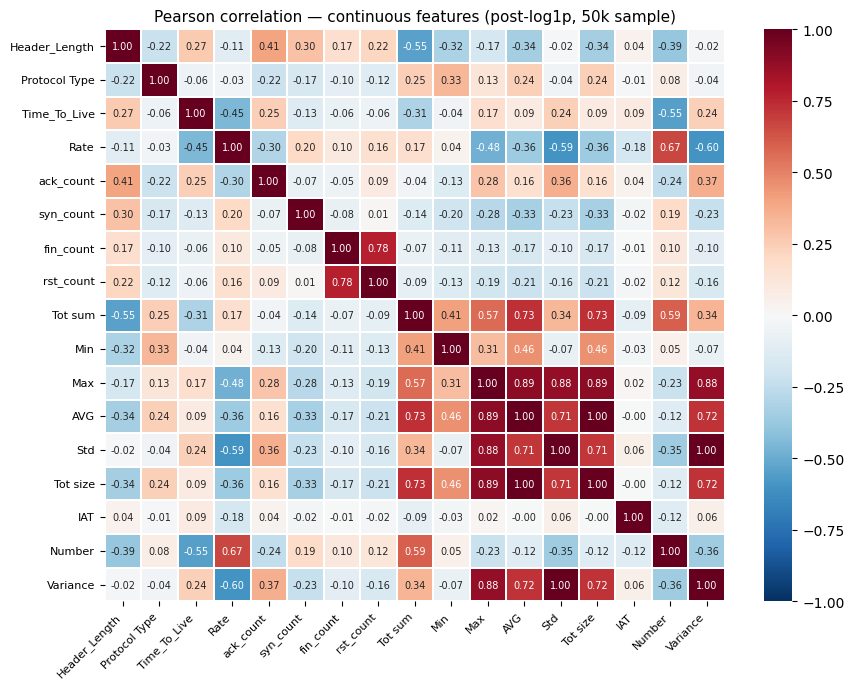

Highly correlated pairs (|r| >= 0.95):
  AVG <-> Tot size: r = 1.000
  Std <-> Variance: r = 0.999


In [14]:
_n_corr = min(50_000, df.shape[0])
_cont = df.sample(n=_n_corr, seed=SEED).select(LOG_COLUMNS).to_numpy().astype(np.float64)
_cont = np.where(np.isnan(_cont), np.nanmean(_cont, axis=0), _cont)
corr = np.corrcoef(_cont.T)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr, xticklabels=LOG_COLUMNS, yticklabels=LOG_COLUMNS,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    linewidths=0.3, ax=ax,
)
ax.set_title('Pearson correlation — continuous features (post-log1p, 50k sample)', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('docs/report/figures/pearson_corr.png', dpi=140, bbox_inches='tight')
plt.show()

threshold = 0.95
pairs = [
    (LOG_COLUMNS[i], LOG_COLUMNS[j], corr[i, j])
    for i in range(len(LOG_COLUMNS))
    for j in range(i + 1, len(LOG_COLUMNS))
    if abs(corr[i, j]) >= threshold
]
if pairs:
    print(f'Highly correlated pairs (|r| >= {threshold}):')
    for a, b, r in sorted(pairs, key=lambda x: -abs(x[2])):
        print(f'  {a} <-> {b}: r = {r:.3f}')
else:
    print(f'No feature pairs with |r| >= {threshold}')
del _cont

#### Correlation findings

Two pairs exceed $|r| \geq 0.95$ and warrant an explicit note.

---

**`Std` vs `Variance` ($r = 0.999$) — mathematical redundancy**

By definition, $\text{Variance} = \text{Std}^2$. After the log1p transform applied in Phase 2:

$$\text{log1p}(\text{Variance}) = \ln(1 + \text{Std}^2)$$

For large values ($\text{Std} \gg 1$), $\ln(1 + x^2) \approx 2\ln(x)$ while $\ln(1+x) \approx \ln(x)$, so:

$$\text{log1p}(\text{Variance}) \approx 2 \cdot \text{log1p}(\text{Std})$$

This is an exact linear rescaling, which is why Pearson $r \approx 1$ post-log1p. `Variance` is dropped; `Std` is retained.

---

**`AVG` vs `Tot size` ($r = 1.000$) — CICFlowMeter artefact**

CICFlowMeter computes:

$$\text{AVG} = \frac{\text{Tot size}}{\text{Number}}$$

For scripted attack traffic the packet count `Number` is near-constant across flows within a session, so `AVG` $\propto$ `Tot size` with an approximately constant ratio. `Tot size` is dropped; `AVG` is retained.

---

**Implication for dimensionality reduction**

These near-duplicate pairs are why PCA would be misleading here: it would construct components mixing them, obscuring their physical meaning. The feature set is instead pruned directly based on redundancy and importance, keeping remaining features interpretable.

#### Spearman rank correlation

Pearson $r$ only sees *linear* coupling. On these heavy-tailed features two columns can be near-perfectly monotonically related yet show a deflated Pearson $r$. Spearman's $\rho$ — Pearson applied to the *ranks* — captures any monotonic relationship and is invariant to the log1p transform. Pairs that score high under Spearman but were not flagged by Pearson are still redundant for an order-based learner (e.g. the tree baselines), so this is the stricter redundancy check.

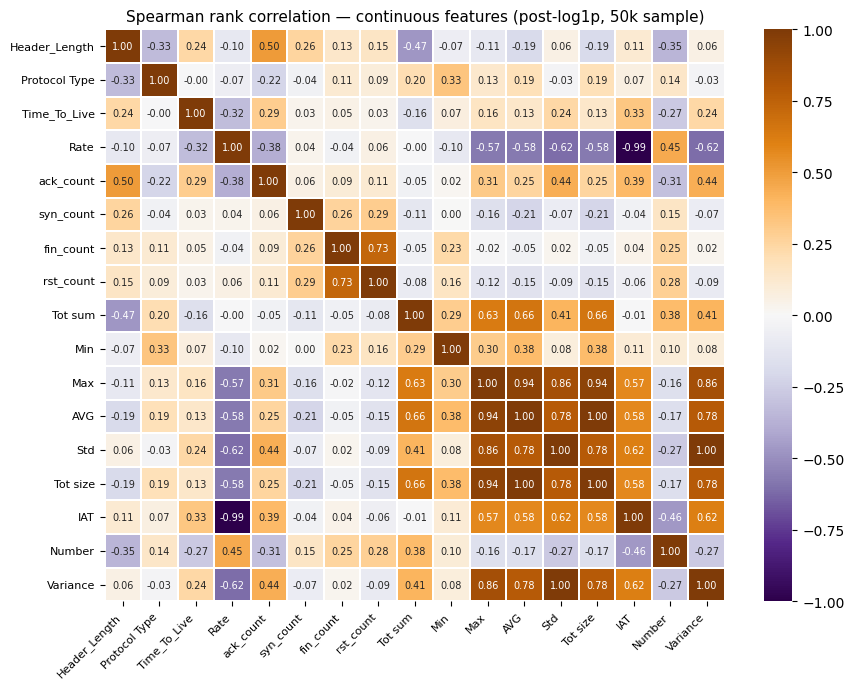

Monotonic pairs (|rho| >= 0.95) that Pearson |r| < 0.95 missed:
  Rate <-> IAT: rho = -0.994  (Pearson r = -0.176)


In [15]:
# Spearman rank correlation = Pearson on column ranks. Catches monotonic
# redundancy that Pearson misses on heavy-tailed features. `corr` is the
# Pearson matrix computed in the heatmap cell above (same LOG_COLUMNS order).
_n_sp = min(50_000, df.shape[0])
_cont_sp = df.sample(n=_n_sp, seed=SEED).select(LOG_COLUMNS).to_numpy().astype(np.float64)
_cont_sp = np.where(np.isnan(_cont_sp), np.nanmean(_cont_sp, axis=0), _cont_sp)
_ranks = np.apply_along_axis(lambda c: c.argsort().argsort(), 0, _cont_sp).astype(np.float64)
spear = np.corrcoef(_ranks.T)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    spear, xticklabels=LOG_COLUMNS, yticklabels=LOG_COLUMNS,
    cmap='PuOr_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    linewidths=0.3, ax=ax,
)
ax.set_title('Spearman rank correlation — continuous features (post-log1p, 50k sample)', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('docs/report/figures/spearman_corr.png', dpi=140, bbox_inches='tight')
plt.show()

# Monotonic pairs Spearman flags that Pearson (|r| >= 0.95) did not.
_thr = 0.95
_extra = [
    (LOG_COLUMNS[i], LOG_COLUMNS[j], spear[i, j], corr[i, j])
    for i in range(len(LOG_COLUMNS))
    for j in range(i + 1, len(LOG_COLUMNS))
    if abs(spear[i, j]) >= _thr and abs(corr[i, j]) < _thr
]
if _extra:
    print(f'Monotonic pairs (|rho| >= {_thr}) that Pearson |r| < {_thr} missed:')
    for a, b, rs, rp in sorted(_extra, key=lambda x: -abs(x[2])):
        print(f'  {a} <-> {b}: rho = {rs:.3f}  (Pearson r = {rp:.3f})')
else:
    print(f'No extra monotonic pairs beyond those Pearson already flags at |.| >= {_thr}')
del _cont_sp, _ranks


#### Feature separability across classes

The variance and correlation checks above prune *redundant* features; this box plot shows which features carry *discriminative* signal. For a chosen continuous feature, the per-family box (median, IQR, whiskers) is drawn on the post-log1p scale the model actually sees.

- **Non-overlapping boxes** — the feature alone separates those families.


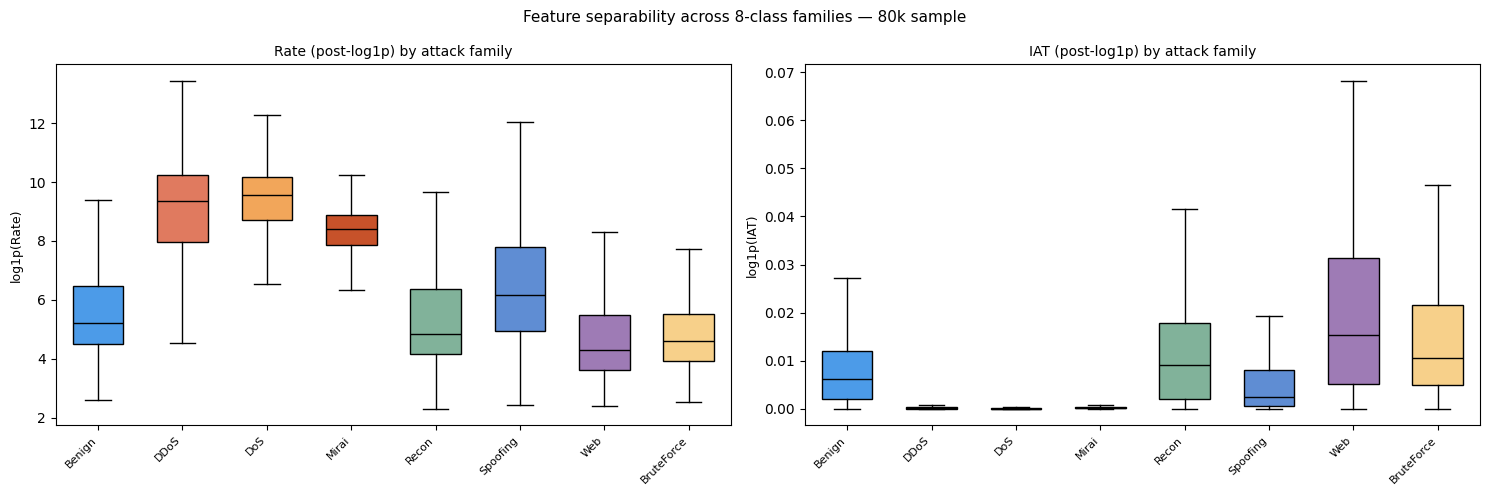

In [16]:
# Class separability: distribution of discriminative features per 8-class family.
_n_sep = min(80_000, df.shape[0])
_sep = df.sample(n=_n_sep, seed=SEED)
_fam = remap_labels(_sep[Y_COLUMN].to_numpy(), '8')

_sep_feats = ['Rate', 'IAT']
fig, axes = plt.subplots(1, len(_sep_feats), figsize=(7.5 * len(_sep_feats), 5))
for ax, feat in zip(np.atleast_1d(axes), _sep_feats):
    vals = _sep[feat].to_numpy().astype(np.float32)
    data = [vals[(_fam == fam) & np.isfinite(vals)] for fam in FAMILY_ORDER]
    bp = ax.boxplot(data, widths=0.6, patch_artist=True, showfliers=False,
                    medianprops=dict(color='black'))
    for patch, fam in zip(bp['boxes'], FAMILY_ORDER):
        patch.set_facecolor(FAMILY_COLORS[fam])
    ax.set_title(f'{feat} (post-log1p) by attack family', fontsize=10)
    ax.set_ylabel(f'log1p({feat})', fontsize=9)
    ax.set_xticks(range(1, len(FAMILY_ORDER) + 1))
    ax.set_xticklabels(FAMILY_ORDER, rotation=45, ha='right', fontsize=8)
fig.suptitle('Feature separability across 8-class families — 80k sample', fontsize=11)
plt.tight_layout()
plt.savefig('docs/report/figures/box_separability_by_family.png', dpi=140, bbox_inches='tight')
plt.show()


#### Feature–target correlation (discriminative signal)

The separability box plots above are read one feature at a time. This bar chart compresses them into a single ranked view: the **point-biserial correlation** of each continuous feature with the binary target — Pearson $r$ with the label encoded as $1$ = Attack, $0$ = Benign. Large $|r|$ means the feature alone tracks the label.

This is also where the `Number` leakage is legible. Because the dataset authors extracted features over a per-class packet window (10 packets for non-flood classes, 100 for floods), `Number` and the count/sum-derived features correlate with the target far more strongly than the window-normalised rate/timing features — a near-label proxy baked into the CSVs, not earned signal. A count feature topping this chart is a warning, not a result.

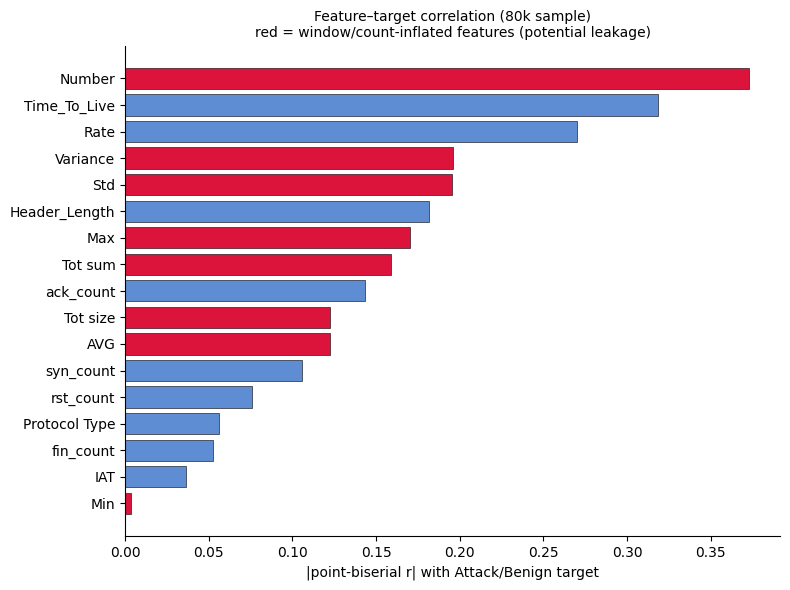

  Number       r = +0.373  <- window/count feature
  Time_To_Live r = -0.319
  Rate         r = +0.270
  Variance     r = -0.196  <- window/count feature
  Std          r = -0.195  <- window/count feature
  Header_Length r = -0.182
  Max          r = -0.170  <- window/count feature
  Tot sum      r = +0.159  <- window/count feature
  ack_count    r = -0.143
  AVG          r = -0.123  <- window/count feature
  Tot size     r = -0.123  <- window/count feature
  syn_count    r = +0.106
  rst_count    r = +0.076
  Protocol Type r = +0.056
  fin_count    r = +0.053
  IAT          r = -0.036
  Min          r = +0.004  <- window/count feature


In [17]:
# Point-biserial correlation of each continuous feature with the binary
# Attack/Benign target (= Pearson r against a 0/1-encoded label).
_n_pb = min(80_000, df.shape[0])
_pb = df.sample(n=_n_pb, seed=SEED)
_y_bin = (remap_labels(_pb[Y_COLUMN].to_numpy(), '2') == 'Attack').astype(np.float64)

pb_corr = []
for feat in LOG_COLUMNS:  # full continuous set — runs before the selection cell
    x = _pb[feat].to_numpy().astype(np.float64)
    m = np.isfinite(x)
    pb_corr.append((feat, np.corrcoef(x[m], _y_bin[m])[0, 1]))

pb_corr.sort(key=lambda t: abs(t[1]))
_count_like = {'Number', 'Tot sum', 'Tot size', 'AVG', 'Min', 'Max', 'Std', 'Variance'}
_colors = ['crimson' if f in _count_like else '#5f8dd3' for f, _ in pb_corr]

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh([f for f, _ in pb_corr], [abs(r) for _, r in pb_corr],
        color=_colors, edgecolor='black', linewidth=0.4)
ax.set_xlabel('|point-biserial r| with Attack/Benign target')
ax.set_title('Feature–target correlation (80k sample)\nred = window/count-inflated features (potential leakage)', fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('docs/report/figures/feature_target_corr.png', dpi=140, bbox_inches='tight')
plt.show()

for f, r in sorted(pb_corr, key=lambda t: -abs(t[1])):
    tag = '  <- window/count feature' if f in _count_like else ''
    print(f'  {f:12} r = {r:+.3f}{tag}')
del _pb, _y_bin


### Feature Selection

Based on the two EDA checks above:
- **Variance check** — drop near-constant binary flags (Var < 0.01)
- **Correlation matrix** — drop exact mathematical duplicates (|r| >= 0.95)

The cell below applies both decisions explicitly, reassigning `X_COLUMNS`, `FLAG_COLUMNS`, `LOG_COLUMNS`, and `N_FEATURES` for all downstream phases.

In [18]:
# Feature selection (39 -> 25), motivated by the EDA above
from ids.core.config import (
    DROPPED_REDUNDANT, DROPPED_LOW_VAR, DROPPED_FEATURES,
    X_COLUMNS_SELECTED, FLAG_COLUMNS_SELECTED, LOG_COLUMNS_SELECTED,
    N_FEATURES_SELECTED,
)

X_COLUMNS    = list(X_COLUMNS_SELECTED)
FLAG_COLUMNS = list(FLAG_COLUMNS_SELECTED)
LOG_COLUMNS  = list(LOG_COLUMNS_SELECTED)
N_FEATURES   = N_FEATURES_SELECTED

print(f'Dropped {len(DROPPED_FEATURES)} features: {len(DROPPED_REDUNDANT)} redundant + {len(DROPPED_LOW_VAR)} near-constant')
print(f'Remaining: {N_FEATURES} features ({len(FLAG_COLUMNS)} flags, {len(LOG_COLUMNS)} continuous)')
print(f'X_COLUMNS: {X_COLUMNS}')


Dropped 14 features: 2 redundant + 12 near-constant
Remaining: 25 features (10 flags, 15 continuous)
X_COLUMNS: ['Header_Length', 'Protocol Type', 'Time_To_Live', 'Rate', 'fin_flag_number', 'syn_flag_number', 'rst_flag_number', 'psh_flag_number', 'ack_flag_number', 'ack_count', 'syn_count', 'fin_count', 'rst_count', 'HTTP', 'HTTPS', 'DNS', 'TCP', 'UDP', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'IAT', 'Number']


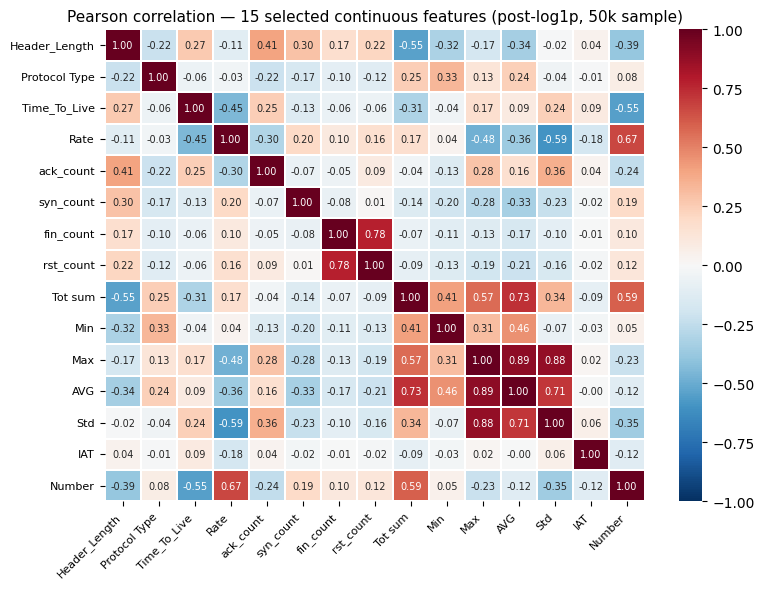

No pairs remain above |r| >= 0.95 — redundancy resolved.


In [19]:
# Pearson correlation on the SELECTED feature set — recomputed here, NOT the
# pre-selection matrix. LOG_COLUMNS was reassigned to the kept continuous
# features in the selection cell above, so this reflects the model's real inputs.
_n_corr2 = min(50_000, df.shape[0])
_cont2 = df.sample(n=_n_corr2, seed=SEED).select(LOG_COLUMNS).to_numpy().astype(np.float64)
_cont2 = np.where(np.isnan(_cont2), np.nanmean(_cont2, axis=0), _cont2)
corr_selected = np.corrcoef(_cont2.T)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    corr_selected, xticklabels=LOG_COLUMNS, yticklabels=LOG_COLUMNS,
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    annot=True, fmt='.2f', annot_kws={'size': 7},
    linewidths=0.3, ax=ax,
)
ax.set_title(f'Pearson correlation — {len(LOG_COLUMNS)} selected continuous features (post-log1p, 50k sample)', fontsize=11)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('docs/report/figures/pearson_corr_selected.png', dpi=140, bbox_inches='tight')
plt.show()

_remaining = [
    (LOG_COLUMNS[i], LOG_COLUMNS[j], corr_selected[i, j])
    for i in range(len(LOG_COLUMNS))
    for j in range(i + 1, len(LOG_COLUMNS))
    if abs(corr_selected[i, j]) >= 0.95
]
if _remaining:
    print('Pairs still above |r| >= 0.95 after selection:')
    for a, b, r in sorted(_remaining, key=lambda x: -abs(x[2])):
        print(f'  {a} <-> {b}: r = {r:.3f}')
else:
    print('No pairs remain above |r| >= 0.95 — redundancy resolved.')
del _cont2


---
## Phase 3: Train/Val/Test Splits — Three Strategies

`train_test_split` on rows assumes IID samples. CIC-IoT-2023 violates this: flows captured 50 ms apart in the same attack session look near-identical in the 39-feature representation. A pure row split puts those near-twins on both sides of the boundary, inflating accuracy. We report **three split strategies** so the gap quantifies how much of the published headline number was within-session memorization:

1. **Temporal** *(headline)* — per attack folder, sort source CSVs by filename and assign the earliest 70% to train, next 15% to val, latest 15% to test. Mirrors deployment: train on past, test on future. Catches concept drift within capture sessions.
2. **Per-CSV** — `GroupShuffleSplit` with source CSV as the group, ensures no CSV is split across train/val/test. Removes within-session leakage but ignores temporal order.
3. **Random row** — original stratified row split. Reported only for parity with published CIC-IoT-2023 numbers (which all use this).

Same per-mode label mapping (2/8) and same `LabelEncoder` logic applied to each split.

**Stratification:** the random split stratifies on the 34-class label (rare-class protection). The per-CSV and temporal splits stratify implicitly via per-folder splitting — every attack class appears in every split as long as its folder has ≥3 CSVs (folders with fewer use a row-level temporal fallback inside the folder).

In [20]:
X_all = df.select(X_COLUMNS).to_numpy().astype(np.float32)
y_all_34 = df[Y_COLUMN].to_numpy()
source_csv_all = df['source_csv'].to_numpy()
del df

SPLIT_INDICES = {}
for name in SPLITS_TO_RUN:
    tr, va, te = SPLIT_FUNCS[name](y_all_34, source_csv_all, SEED)
    SPLIT_INDICES[name] = (tr, va, te)
    print(f'{name:>10}: train {len(tr):>10,} | val {len(va):>10,} | test {len(te):>10,}')

# Sanity: every split should cover every 34-class
for name, (tr, va, te) in SPLIT_INDICES.items():
    missing = set(np.unique(y_all_34)) - set(np.unique(y_all_34[tr]))
    if missing:
        print(f'  WARNING ({name}): {len(missing)} classes absent from train: {missing}')

    random: train  3,113,777 | val    667,238 | test    667,238


---
## Phase 4: Train-Fit Imputation + Robust Scaling

For each split: compute column medians on **train only**, fill val/test nulls with those medians, then `RobustScaler` (also fit on train only). Both fits stay strictly on the training partition for that split — no information leaks from val/test into the preprocessing.

In [21]:
_split = SPLITS_TO_RUN[0]
_tr, _va, _te = SPLIT_INDICES[_split]
_X_tr, _X_va, _X_te, _prep = fit_preprocess(X_all, _tr, _va, _te)

_total = len(_tr) + len(_va) + len(_te)
print(f'Split "{_split}": train {len(_tr):,} ({len(_tr)/_total:.0%}) | val {len(_va):,} ({len(_va)/_total:.0%}) | test {len(_te):,} ({len(_te)/_total:.0%})')

null_cols = [X_COLUMNS[i] for i in range(len(X_COLUMNS)) if np.isnan(X_all[_tr, i]).any()]
print(f'Median-imputed columns: {null_cols}')
print(f'Scaler center range:  [{_prep.scaler.center_.min():.3f}, {_prep.scaler.center_.max():.3f}]')
print(f'Scaler scale (IQR):   [{_prep.scaler.scale_.min():.3f}, {_prep.scaler.scale_.max():.3f}]')

del _X_tr, _X_va, _X_te, _prep

Split "random": train 3,113,777 (70%) | val 667,238 (15%) | test 667,238 (15%)
Median-imputed columns: ['Rate', 'Std', 'IAT', 'Number']
Scaler center range:  [0.000, 2.273]
Scaler scale (IQR):   [0.001, 1.878]


---
## Phase 5: Dataset, Model, Training Utilities

- `IDSDataset` — tensor wrapper for DataLoader
- `IDSModel` — 2-layer MLP with BatchNorm + Dropout
- `train_model` — class-weighted CE, early stopping on val loss
- `evaluate` — metrics + confusion matrix on test

BatchNorm stabilizes training under large class-weight swings (34-class weights can span 50×+ the minimum).

In [22]:
_model_demo = IDSModel(N_FEATURES, n_classes=34)
print(_model_demo)
n_params = sum(p.numel() for p in _model_demo.parameters())
print(f'Total trainable parameters: {n_params:,}')
del _model_demo

IDSModel(
  (net): Sequential(
    (0): Linear(in_features=25, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=64, out_features=34, bias=True)
  )
)
Total trainable parameters: 14,178


In [23]:
# True:  load the cached metrics of the last training run (no retraining).
# False: retrain everything via the training package (same as `python -m training`).
SKIP_TRAINING = True


---
## Phase 5b: Hyperparameter Optimisation (Optuna)

Before committing to a fixed architecture, we search the MLP hyperparameter space using **Optuna** with the TPE (Tree-structured Parzen Estimator) sampler and MedianPruner.

**Search space:**

| Parameter | Range | Scale |
|---|---|---|
| `n_layers` | 2 – 4 | categorical |
| `hidden_size` per layer | 64 – 512 | int (step 32) |
| `dropout` | 0.1 – 0.5 | float |
| `lr` | 1e-4 – 1e-2 | log |
| `optimizer` | Adam, AdamW | categorical |
| `batch_size` | 1024, 2048, 4096, 8192 | categorical |
| `activation` | ReLU, ELU, LeakyReLU | categorical |

Each trial trains on the temporal split's train partition and is evaluated on validation loss. The **MedianPruner** kills unpromising trials after 5 epochs if their val loss exceeds the median of completed trials, making the search ~3× faster.

The best hyperparameters are printed and used for the final training run in Phase 6.

In [24]:
if not SKIP_TRAINING:
    from ids.training.tune import run_hpo

    best_params = run_hpo(
        X_all, y_all_34, SPLIT_INDICES, remap_labels,
        device, seed=SEED, n_trials=15, tune_epochs=10,
    )

    BEST_HIDDEN  = [best_params[f'hidden_{i}'] for i in range(best_params['n_layers'])]
    BEST_DROPOUT = best_params['dropout']
    BEST_LR      = best_params['lr']
    BEST_OPT     = best_params['optimizer']
    BEST_BATCH   = best_params['batch_size']
    BEST_ACT     = best_params['activation']
    print(f'Architecture: {N_FEATURES} -> ' + ' -> '.join(str(h) for h in BEST_HIDDEN) + ' -> n_classes')
else:
    print('SKIP_TRAINING=True — skipping Optuna search.')


SKIP_TRAINING=True — skipping Optuna search.


---
## Phase 6: Training (via the `training` package)

All training is orchestrated by `training.run_training` — the same code path as
the headless `python -m training`. For each `(split, mode)` it:
- slices `X_all`/`y_all_34` with the split's train/val/test indices and fits
  median imputation + RobustScaler on train only;
- remaps labels (2/8), fits the `LabelEncoder`, computes train-only class weights;
- trains the MLP (class-weighted CE, ReduceLROnPlateau, early stopping) and the
  RF/XGBoost baselines, evaluating each on train/val/test;
- persists every artifact (weights, scaler, encoders, logits, run history) plus
  the permutation importance and the temperature-scaling calibration.

The cell below either runs it or, with `SKIP_TRAINING=True`, loads the metrics
cache (`_results_full.joblib`) written by the last run.


In [25]:
from ids.training import run_training
from ids.training import artifacts, plots

if SKIP_TRAINING:
    print('SKIP_TRAINING=True — loading cached results from the last training run.')
    _cached = artifacts.load_results()
    RESULTS_ALL, CALIBRATION = _cached['splits'], _cached['calibration']
    TRAINED_MODELS, ENCODERS = {}, {}
else:
    _out = run_training(splits=SPLITS_TO_RUN, modes=MODES_TO_RUN, wandb_enabled=False)
    RESULTS_ALL, CALIBRATION = _out['splits'], _out['calibration']
    TRAINED_MODELS, ENCODERS = _out['models'], _out['encoders']

R = RESULTS_ALL[SPLITS_TO_RUN[0]]   # headline-split results used by the cells below


SKIP_TRAINING=True — loading cached results from the last training run.


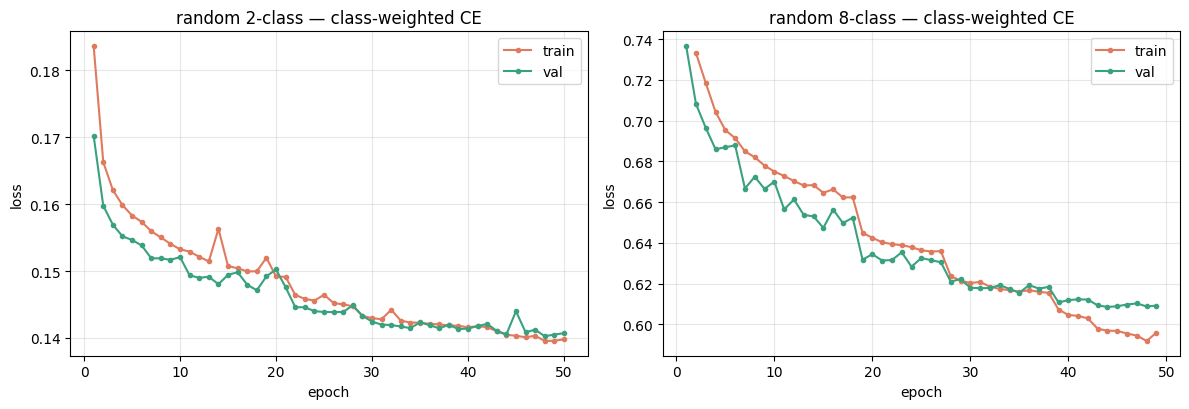

In [26]:
from ids.training import artifacts, plots

_split = SPLITS_TO_RUN[0]
_histories = {mode: artifacts.load_run_artifacts(_split, mode)['history']
              for mode in MODES_TO_RUN}
fig = plots.plot_training_curves(_histories, _split)
fig.savefig('docs/report/figures/training_curves.png', dpi=140, bbox_inches='tight')
plt.show()


---
## Phase 7: Comparison & Reports

In [27]:
for mode in MODES_TO_RUN:
    print(f'\n===== {SPLITS_TO_RUN[0]} / {mode}-class classification report (MLP) =====')
    print(R[f'mlp_report_{mode}'])



===== random / 2-class classification report (MLP) =====
              precision    recall  f1-score   support

      Attack     0.9991    0.9109    0.9530    637238
      Benign     0.3417    0.9823    0.5071     30000

    accuracy                         0.9141    667238
   macro avg     0.6704    0.9466    0.7300    667238
weighted avg     0.9695    0.9141    0.9329    667238


===== random / 8-class classification report (MLP) =====
              precision    recall  f1-score   support

      Benign     0.5982    0.7244    0.6553     30000
  BruteForce     0.0759    0.6187    0.1353      1959
        DDoS     0.9763    0.7009    0.8160    307833
         DoS     0.5102    0.9488    0.6636    100723
       Mirai     0.9961    0.9980    0.9971     90000
       Recon     0.9234    0.5916    0.7212     76881
    Spoofing     0.9403    0.8044    0.8671     56132
         Web     0.1140    0.5892    0.1910      3710

    accuracy                         0.7747    667238
   macro avg   

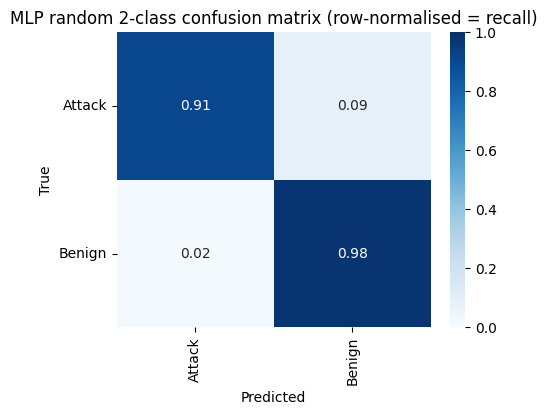

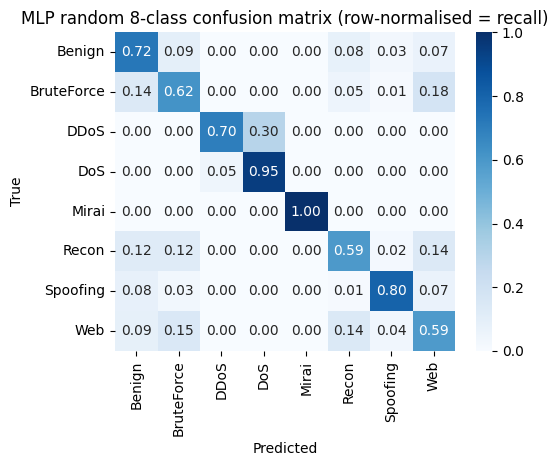

In [28]:
from ids.training import plots

for mode in MODES_TO_RUN:
    fig = plots.plot_confusion(
        R[f'mlp_cm_{mode}'], R[f'class_names_{mode}'],
        title=f'MLP {SPLITS_TO_RUN[0]} {mode}-class confusion matrix (row-normalised = recall)')
    fig.savefig(f'docs/report/figures/confusion_{mode}class.png', dpi=140, bbox_inches='tight')
    plt.show()


In [29]:
header = f'{"Split":<10}{"Mode":<6}{"Model":<6}{"Accuracy":<12}{"MacroF1":<12}{"WeightedF1":<14}{"MacroPrec":<12}{"MacroRec":<12}'
print(header)
print('-' * len(header))
for split_name, R_ in RESULTS_ALL.items():
    for mode in MODES_TO_RUN:
        for kind in ('mlp', 'rf'):
            m = R_.get((f'mode{mode}', kind, 'test'))
            if m is None:
                continue
            print(f'{split_name:<10}{mode:<6}{kind:<6}{m["accuracy"]:<12.4f}{m["macro_f1"]:<12.4f}'
                  f'{m["weighted_f1"]:<14.4f}{m["macro_precision"]:<12.4f}{m["macro_recall"]:<12.4f}')
    print()


Split     Mode  Model Accuracy    MacroF1     WeightedF1    MacroPrec   MacroRec    
------------------------------------------------------------------------------------
random    2     mlp   0.9141      0.7300      0.9329        0.6704      0.9466      
random    2     rf    0.9506      0.7984      0.9578        0.7349      0.9304      
random    8     mlp   0.7747      0.6308      0.7981        0.6418      0.7470      
random    8     rf    0.8308      0.7008      0.8402        0.6865      0.7358      



### Gate decision rates: FPR and FNR for the 4 models

The cross-model table above reports the aggregate metrics. For the **2-class model
acting as the alert gate**, the two rates that actually decide its fitness are the
ones an operator feels: false alarms and missed attacks. Both follow directly from
the per-class recalls in the classification reports already cached for every model,
so no retraining is needed.

- **FPR** (false-positive rate) $= 1 - \text{recall}(\text{Benign})$ — legitimate flows
  flagged as attacks. This is the false-alarm rate the gate is judged on.
- **FNR** (false-negative rate) $= 1 - \text{recall}(\text{Attack})$ — attacks predicted
  benign, i.e. missed intrusions. Well-defined for the 2-class gate; for the 8-class
  models a single "missed attack" rate is not meaningful (the attack mass is spread
  over seven families), so it is shown as n/a there.

The decision is plain argmax (threshold 0.5); these rates are the operating point the
follow-up threshold sweep would move along.

In [30]:
# FPR/FNR for the 4 models = {MLP, RF} x {2-class, 8-class}, from the cached reports.
def _parse_report(rep: str) -> dict:
    """sklearn classification_report text -> {class_name: {'precision','recall','f1','support'}}.
    Our class names contain no spaces, so a class row is exactly 5 whitespace tokens."""
    out = {}
    for line in rep.splitlines():
        toks = line.split()
        if len(toks) == 5 and toks[0] not in ('accuracy', 'macro', 'weighted'):
            try:
                out[toks[0]] = {'precision': float(toks[1]), 'recall': float(toks[2]),
                                'f1': float(toks[3]), 'support': int(toks[4])}
            except ValueError:
                pass
    return out


def _cell(x, w):  # right-pad a float, or 'n/a' for None/NaN
    return f'{x:<{w}.4f}' if (x is not None and x == x) else f'{"n/a":<{w}}'


_hdr = (f'{"Model":<6}{"Mode":<8}{"Accuracy":<11}{"MacroF1":<10}{"WeightedF1":<12}'
        f'{"BenignRec":<11}{"FPR":<9}{"AttackRec":<11}{"FNR":<9}')
print(_hdr)
print('-' * len(_hdr))
for mode in MODES_TO_RUN:
    for kind in ('mlp', 'rf'):
        m = R.get((f'mode{mode}', kind, 'test'))
        rep = R.get(f'{kind}_report_{mode}')
        if m is None or rep is None:
            continue
        pc = _parse_report(rep)
        ben_rec = pc.get('Benign', {}).get('recall')                 # = TNR
        fpr = (1 - ben_rec) if ben_rec is not None else None
        atk_rec = pc.get('Attack', {}).get('recall') if mode == '2' else None
        fnr = (1 - atk_rec) if atk_rec is not None else None
        print(f'{kind.upper():<6}{mode + "-class":<8}'
              f'{m["accuracy"]:<11.4f}{m["macro_f1"]:<10.4f}{m["weighted_f1"]:<12.4f}'
              f'{_cell(ben_rec, 11)}{_cell(fpr, 9)}{_cell(atk_rec, 11)}{_cell(fnr, 9)}')
    print()
print('FPR = 1 - Benign recall (legit flow flagged as attack).  '
      'FNR = 1 - Attack recall (missed attack; 2-class gate only).')

Model Mode    Accuracy   MacroF1   WeightedF1  BenignRec  FPR      AttackRec  FNR      
---------------------------------------------------------------------------------------
MLP   2-class 0.9141     0.7300    0.9329      0.9823     0.0177   0.9109     0.0891   
RF    2-class 0.9506     0.7984    0.9578      0.9081     0.0919   0.9526     0.0474   

MLP   8-class 0.7747     0.6308    0.7981      0.7244     0.2756   n/a        n/a      
RF    8-class 0.8308     0.7008    0.8402      0.7871     0.2129   n/a        n/a      

FPR = 1 - Benign recall (legit flow flagged as attack).  FNR = 1 - Attack recall (missed attack; 2-class gate only).


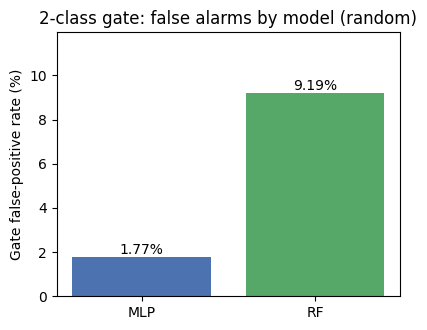

In [31]:
# Gate (2-class) false-positive rate by model: the figure that picks the gate model.
import matplotlib.pyplot as plt

_fpr = {}
for kind in ('mlp', 'rf'):
    rep = R.get(f'{kind}_report_2')
    if rep:
        ben = _parse_report(rep).get('Benign', {}).get('recall')
        if ben is not None:
            _fpr[kind] = (1 - ben) * 100

if _fpr:
    fig, ax = plt.subplots(figsize=(4.2, 3.4))
    names = [k.upper() for k in _fpr]
    vals = [_fpr[k] for k in _fpr]
    bars = ax.bar(names, vals, color=['#4C72B0', '#55A868'][:len(vals)])
    ax.set_ylabel('Gate false-positive rate (%)')
    ax.set_title(f'2-class gate: false alarms by model ({SPLITS_TO_RUN[0]})')
    ax.set_ylim(0, max(vals) * 1.3)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.2f}%', ha='center', va='bottom')
    fig.tight_layout()
    fig.savefig('docs/report/figures/gate_fpr_by_model.png', dpi=140, bbox_inches='tight')
    plt.show()
else:
    print('No 2-class reports in the results cache. '
          'Run training first (SKIP_TRAINING=False) or load a cache that has them.')

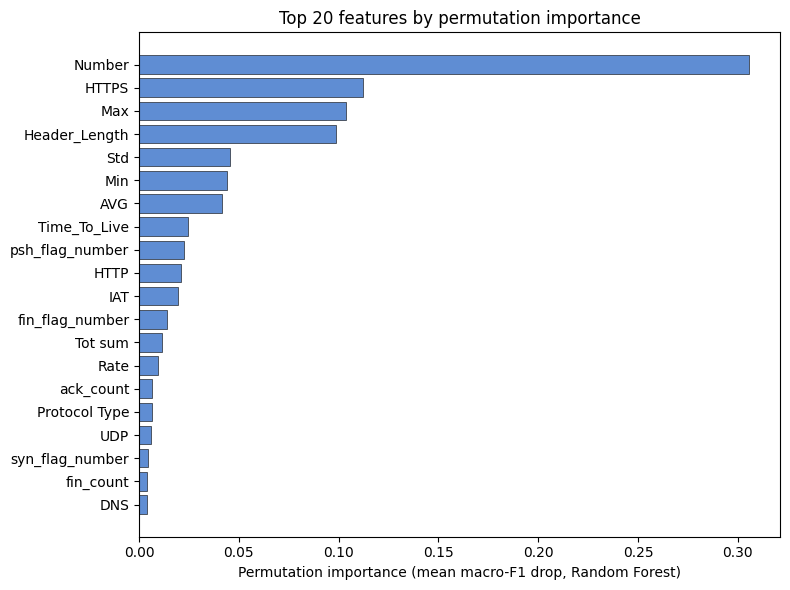

In [32]:
from ids.training import plots

if 'perm_importance_8' in R:
    fig = plots.plot_permutation_importance(R['perm_importance_8'])
    fig.savefig('docs/report/figures/feature_importance.png', dpi=140, bbox_inches='tight')
    plt.show()
else:
    print('perm_importance_8 missing from the cache — rerun training.')


#### Feature importance: permutation importance

Feature importance is measured by **permutation importance** on the held-out test
set: a feature's values are randomly shuffled, breaking its association with the
label, and the resulting drop in macro-F1 is the feature's importance. Unlike the
trees' built-in Gini importance, this is model-agnostic, measured on unseen data,
and comparable across model families. The figure shows the RF + XGBoost average —
the same statistic reported in the thesis.


In [33]:
# Optional (slow) analysis: per-family permutation importance heatmap.
# Requires in-memory fitted models, so it only runs after a fresh training run.
if not SKIP_TRAINING and (SPLITS_TO_RUN[0], '8', 'rf') in TRAINED_MODELS:
    from ids.training.evaluation import per_family_permutation_importance
    from ids.training import plots

    _split = SPLITS_TO_RUN[0]
    rf_model = TRAINED_MODELS[(_split, '8', 'rf')]
    le8 = ENCODERS[(_split, '8')]
    tr_idx, va_idx, te_idx = SPLIT_INDICES[_split]
    _, _, X_te_, _ = fit_preprocess(X_all, tr_idx, va_idx, te_idx)
    y_test_34 = y_all_34[te_idx]
    y_test_enc = np.asarray(le8.transform(remap_labels(y_test_34, '8')))

    families, matrix = per_family_permutation_importance(
        rf_model, X_te_, y_test_34, y_test_enc, DICT_8CLASSES, X_COLUMNS, SEED)
    fig = plots.plot_family_importance_heatmap(families, matrix, X_COLUMNS)
    plt.show()
else:
    print('Per-family importance needs a fresh run: set SKIP_TRAINING=False and retrain.')


Per-family importance needs a fresh run: set SKIP_TRAINING=False and retrain.


---
## Phase 8c: Cross-Model Performance — Weighted F1 Across Partitions

Compare MLP, RF, and XGBoost on the train/validation/test partitions from the
results cache (the figure reported in the thesis), followed by the reliability
diagram of the calibrated MLP.


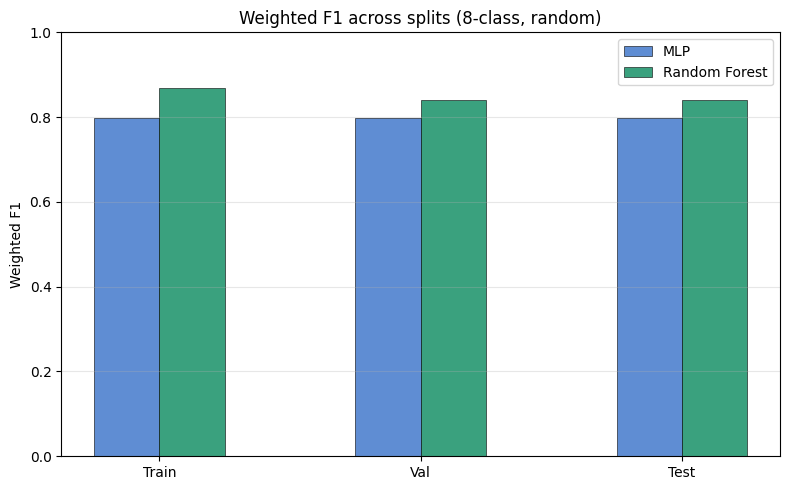

In [34]:
from ids.training import plots

fig = plots.plot_splits_bar(
    R, mode='8', key='weighted_f1',
    title=f'Weighted F1 across splits (8-class, {SPLITS_TO_RUN[0]})',
    ylabel='Weighted F1')
fig.savefig('docs/report/figures/weighted_f1_splits.png', dpi=140, bbox_inches='tight')
plt.show()


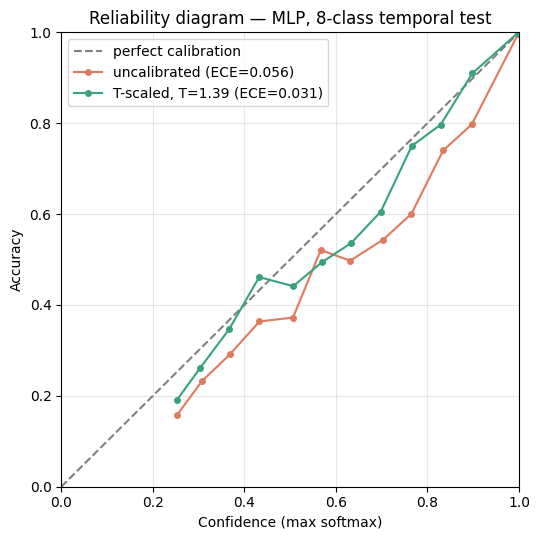

In [35]:
# Reliability diagram (8-class): needs the MLP logits saved by the last training run.
from ids.training import artifacts, plots

_split = SPLITS_TO_RUN[0]
if artifacts.logits_path(_split, '8').exists():
    d = artifacts.load_logits(_split, '8')
    c8 = CALIBRATION['8']
    fig = plots.plot_reliability(d['test_logits'], d['test_y'], c8['T'],
                                 c8['ece_before'], c8['ece_after'],
                                 title='Reliability diagram — MLP, 8-class temporal test')
    fig.savefig('docs/report/figures/reliability_8class.png', dpi=140, bbox_inches='tight')
    plt.show()
else:
    print(f'{artifacts.logits_path(_split, "8")} not found — run training first.')


---
## Phase 9: Inference Benchmark

**Latency target:** end-to-end inference under ~100 ms for a single flow on the demo host. This is sufficient for **interactive single-request inference** in the demo (user clicks, sees verdict). It is **not** a line-rate gateway claim — line-rate (10 Gbps / >1M flows/sec) is explicitly out of scope.

For each MLP model, measured at batch sizes `[1, 32, 256, 1024]`:
- **End-to-end latency** including `scaler.transform` (the demo path, not just `model(x)`)
- **p50 / p95 / p99** over 1000 runs per batch size (after 100 warmup runs)
- **Throughput** in flows/sec

`torch.cuda.synchronize()` is called before/after timing on CUDA devices so we measure execution rather than kernel-launch latency.

In [36]:
from ids.training import artifacts

print(f'{"Split":<10}{"Mode":<6}{"Batch":<8}{"p50 ms":<10}{"p95 ms":<10}{"p99 ms":<10}{"flows/sec":<14}')
print('-' * 70)
for split_name in SPLITS_TO_RUN:
    prep = joblib.load(artifacts.preprocessor_path(split_name))
    tr_idx, _, _ = SPLIT_INDICES[split_name]
    pool = X_all[tr_idx[:10_000]]
    pool = np.where(np.isnan(pool), 0.0, pool).astype(np.float32)

    for mode in MODES_TO_RUN:
        model, _le = artifacts.load_mlp(split_name, mode, N_FEATURES)
        for bs in BATCH_SIZES:
            stats = benchmark_model(model, prep, pool, bs, N_WARMUP, N_RUNS, device, SEED)
            print(f'{split_name:<10}{mode:<6}{bs:<8}'
                  f'{stats["p50_ms"]:<10.3f}{stats["p95_ms"]:<10.3f}{stats["p99_ms"]:<10.3f}'
                  f'{stats["throughput_flows_per_sec"]:<14,.0f}')


Split     Mode  Batch   p50 ms    p95 ms    p99 ms    flows/sec     
----------------------------------------------------------------------


RuntimeError: Error(s) in loading state_dict for IDSModel:
	Unexpected key(s) in state_dict: "net.9.weight", "net.9.bias", "net.9.running_mean", "net.9.running_var", "net.9.num_batches_tracked", "net.12.weight", "net.12.bias". 
	size mismatch for net.0.weight: copying a param with shape torch.Size([512, 25]) from checkpoint, the shape in current model is torch.Size([128, 25]).
	size mismatch for net.0.bias: copying a param with shape torch.Size([512]) from checkpoint, the shape in current model is torch.Size([128]).
	size mismatch for net.1.weight: copying a param with shape torch.Size([512]) from checkpoint, the shape in current model is torch.Size([128]).
	size mismatch for net.1.bias: copying a param with shape torch.Size([512]) from checkpoint, the shape in current model is torch.Size([128]).
	size mismatch for net.1.running_mean: copying a param with shape torch.Size([512]) from checkpoint, the shape in current model is torch.Size([128]).
	size mismatch for net.1.running_var: copy

## Reproducing the trained artifacts, metrics, and calibration

All training (MLP + RF + XGBoost), evaluation, permutation importance, and
temperature-scaling calibration live in the **`training/` package** — this
notebook only orchestrates it (the `run_training` cell above) and renders the
figures. The same run, headless, is one command from the project root:

```bash
python -m training --splits temporal --modes 2 8
```

This regenerates `models/*` (including `temperature_scaling.joblib`, which the
demo loads for calibrated confidence), `_results_full.joblib` (the metrics cache
this notebook loads when `SKIP_TRAINING=True`), and `_paper_numbers.json` (the
numbers cited in the thesis). Every figure in the thesis is produced and saved by
this notebook: the EDA figures from the ingest/EDA cells, the results figures
from the plot cells above — all written to `docs/report/figures/`.
